# Tutorial: Simulação Transiente e Propagação de Pulso Térmico no Marlim 3

Neste tutorial, vamos explorar como configurar e executar uma simulação puramente transiente no simulador de escoamento multifásico Marlim 3. 

Nosso objetivo é simular a injeção de um fluido quente, através de um pulso térmico, em uma tubulação que inicialmente encontra-se a 20 °C, mas que está exposta a um ambiente externo submarino frio de 4 °C. Mais do que apenas aplicar um revestimento e ver o resultado, queremos estudar detalhadamente como essa onda de calor se propaga ao longo do tempo e da extensão do duto.

No ambiente submarino, se o fluido perder muito calor para o mar e sua temperatura cair abaixo de limites críticos, componentes da mistura podem cristalizar. Isso resulta na formação de tampões sólidos de hidrato ou na forte deposição de parafinas, entupindo a linha e interrompendo a produção.

Para demonstrar a importância de gerenciar essa perda de energia, executaremos o nosso cenário de propagação térmica duas vezes:
1. **Com a tubulação de aço nu (sem isolamento):** para observarmos a rápida dissipação da onda de calor ao longo da linha.
2. **Com a adição de uma camada de isolamento térmico de Espuma de Polietileno:** para avaliarmos a capacidade de retenção térmica e a preservação do pulso.

Ao final, compararemos graficamente a evolução temporal em diferentes pontos de monitoramento da linha, provando visualmente como o isolamento dita a viabilidade e a segurança do escoamento.

In [1]:
import marlim3
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt

## 1. Configurações Globais e Condições de Contorno

O primeiro passo é instanciar o caso de estudo e definir as configurações gerais.

In [2]:
# Inicializa o objeto principal do Marlim 3
caso = marlim3.Tramo()

# Configurações iniciais
caso.configuracaoInicial = {
    "transiente": True,
    "condicaoInicial": 0,
    "iniFluidoP": 0
}

# Controle de tempo da simulação
caso.tempo = {
    "tempoFinal": 3000.0, 
    "tempos": [0.0], 
    "dtmax": [0.4]
}

# Definição do fluido de produção (Óleo 35.95 API, sem gás livre ou água inicial)
caso.fluidosProducao = [{
    "id": 0,
    "api": 35.95,
    "rgo": 0.0,
    "densidadeGas": 0.845, 
    "bsw": 0.0
}]

# Condição de contorno na saída
caso.separador = {
    "tempo": [0], 
    "pressao": [15.0]
}

# Condição de contorno na entrada
# Simulamos um pulso térmico: o fluido entra a 20°C, sobe para 80°C entre 1000s e 1500s, e retorna para 20°C.
caso.fonteLiquido = [{
    "id": 0, 
    "indiFluidoPro": 0, 
    "comprimentoMedido": 0.0,
    "tempo": [0, 999, 1000, 1499, 1500, 3000],
    "temperatura": [20.0, 20.0, 80.0, 80.0, 20.0, 20.0],
    "vazaoLiquido": [3000, 3000, 3000, 3000, 3000, 3000]
}]

## 2. Configurando a Aquisição de Dados (Sensores)

Para monitorar a onda de calor propagando-se pela tubulação, vamos espalhar sensores (tendências pontuais) a cada 100 metros ao longo da linha.

In [ ]:
# Define posições de 0m a 1000m
secoes_monitoradas = [100 * i for i in range(0, 11)]

caso.tendP = [{"ativo": True, 
               "comprimentoMedido": pos,
               "dt": 1.0, 
               "rotulo": f"PIPE-1_Sec_{int(pos)}m", 
               "temperatura": True, 
               "Hext": True
               } for pos in secoes_monitoradas]

## 3. Materiais e Seções Transversais

Nesta etapa, definimos as propriedades termofísicas dos materiais envolvidos. A condutividade térmica e a capacidade calorífica ditam como a parede do duto armazena e perde calor para o ambiente. 

Criaremos duas seções transversais diferentes para podermos alterná-las durante o estudo comparativo.

In [4]:
# Cadastro de materiais na base de dados do modelo
caso.material = [{"id": 0, 
                  "rotulo": "Carbon Steel", 
                  "tipo": 0, 
                  "condutividade": 45.0,
                  "calorEspecifico": 470.0, 
                  "rho": 7850.0},
                  
                  {"id": 1, 
                   "rotulo": "Poly_Ethylene_Foam",
                   "tipo": 0, 
                   "condutividade": 0.04, 
                   "calorEspecifico": 2300.0, 
                   "rho": 32.0}
                ]

# Seção 1: Tubulação apenas com aço carbono
secao_sem_isolamento = {"id": 0,
                        "rotulo": "Secao_Sem_Isolamento",
                        "diametroInterno": 0.1524,
                        "rugosidade": 5e-05,
                        "camadas": [{"rotulo": "Tube Wall - Steel", 
                                     "idMaterial": 0, 
                                     "tipoMedicaoCamada": "ESPESSURA", 
                                     "espessura": 0.0071,
                                     "discretizacao": 3}]
                        }

# Seção 2: Tubulação de aço carbono revestida com 25mm de Espuma de Polietileno
secao_com_isolamento = {"id": 1,
                        "rotulo": "Secao_Com_Isolamento_PE",
                        "diametroInterno": 0.1524,
                        "rugosidade": 5e-05,
                        "camadas": [{"rotulo": "Tube Wall - Steel", 
                                     "idMaterial": 0, 
                                     "tipoMedicaoCamada": "ESPESSURA",
                                     "espessura": 0.0071,
                                     "discretizacao": 3},

                                    {"rotulo": "Isolante - Foam", 
                                     "idMaterial": 1, 
                                     "tipoMedicaoCamada": "ESPESSURA", 
                                     "espessura": 0.025,
                                     "discretizacao": 10}]
                    }

# Atribui as duas opções ao modelo
caso.secaoTransversal = [secao_sem_isolamento, secao_com_isolamento]

## 4. Simulação comparativa

Aqui estruturamos a topologia do duto e o estado termofluidodinâmico inicial. O script roda o Marlim 3 para cada configuração de revestimento e guarda as saídas.

In [5]:
# Configuração base do duto
caso.dutosProducao = [{"id": 0,
                       "rotulo": "PIPE-1", 
                       "idCorte": 0,          # Este ID será alterado dinamicamente no loop
                       "angulo": 0.0,
                       "ambienteExterno": 0,
                       "discretizacao": [{"nCelulas": 100, "comprimento": 5.0}],
                       "condicoesIniciais": {
                           "compInter": [0, 1],
                           "temp": [20.0, 20.0],      
                           "pressao": [15.0, 15.0],   
                           "holdup": [1.0, 1.0],      
                           "bet": [0.0, 0.0],
                           "uls": [1.9, 1.9],         
                           "ugs": [0.0, 0.0],
                           "tempExterna": [4.0, 4.0],
                           "velExterna": [0.3, 0.3],
                           "kExterna": [0.6, 0.6],
                           "calorEspecificoExterno": [3990.0, 3990.0],
                           "rhoExterno": [1025.0, 1025.0],
                           "viscExterna": [1.5, 1.5]}
                    }]

# Definindo os cenários para o loop
casos_estudo = [
    {"nome": "sem_isolamento", "id_corte": 0, "titulo": "Aço Nu (Sem Isolamento)"},
    {"nome": "com_isolamento", "id_corte": 1, "titulo": "Com Espuma de Polietileno"}
]

pasta_padrao = "marlim3_resultados"

for c in casos_estudo:
    
    # 1. Altera qual seção transversal o duto irá utilizar
    caso.dutosProducao[0]["idCorte"] = c["id_corte"]
    
    # 2. Executa a simulação
    caso.simular()
    
    # 3. Renomeia a pasta de saída
    pasta_destino = f"resultados_{c['nome']}"
    if os.path.exists(pasta_destino):
        shutil.rmtree(pasta_destino)
    os.rename(pasta_padrao, pasta_destino)

------------------------------------------   Eventos no Tramo -------------------------------------------
0  momento = 999 segundos  tipo de evento = Aumentando temperatura de Liquido, Fonte
1  momento = 1499 segundos  tipo de evento = Diminuindo temperatura de Liquido, Fonte
0 % da simulacao alcancado
5.00267 % da simulacao alcancado
10.0053 % da simulacao alcancado
14.9973 % da simulacao alcancado
20 % da simulacao alcancado
25.0027 % da simulacao alcancado
29.9947 % da simulacao alcancado
34.9973 % da simulacao alcancado
40 % da simulacao alcancado
45.0027 % da simulacao alcancado
50.0053 % da simulacao alcancado
54.9973 % da simulacao alcancado
60 % da simulacao alcancado
65.0027 % da simulacao alcancado
70.0053 % da simulacao alcancado
74.9973 % da simulacao alcancado
80 % da simulacao alcancado
85.0027 % da simulacao alcancado
89.9947 % da simulacao alcancado
94.9973 % da simulacao alcancado
99.9893 % da simulacao alcancado
********************************************************

## 5. Pós-Processamento e Visualização de Resultados

Finalmente, utilizamos `pandas` e `matplotlib` para ler os dados binários/CSV gerados pelo Marlim 3 e visualizar o impacto do isolamento. Plotaremos as tendências pontuais (*trendplots*) dos três primeiros sensores da tubulação.

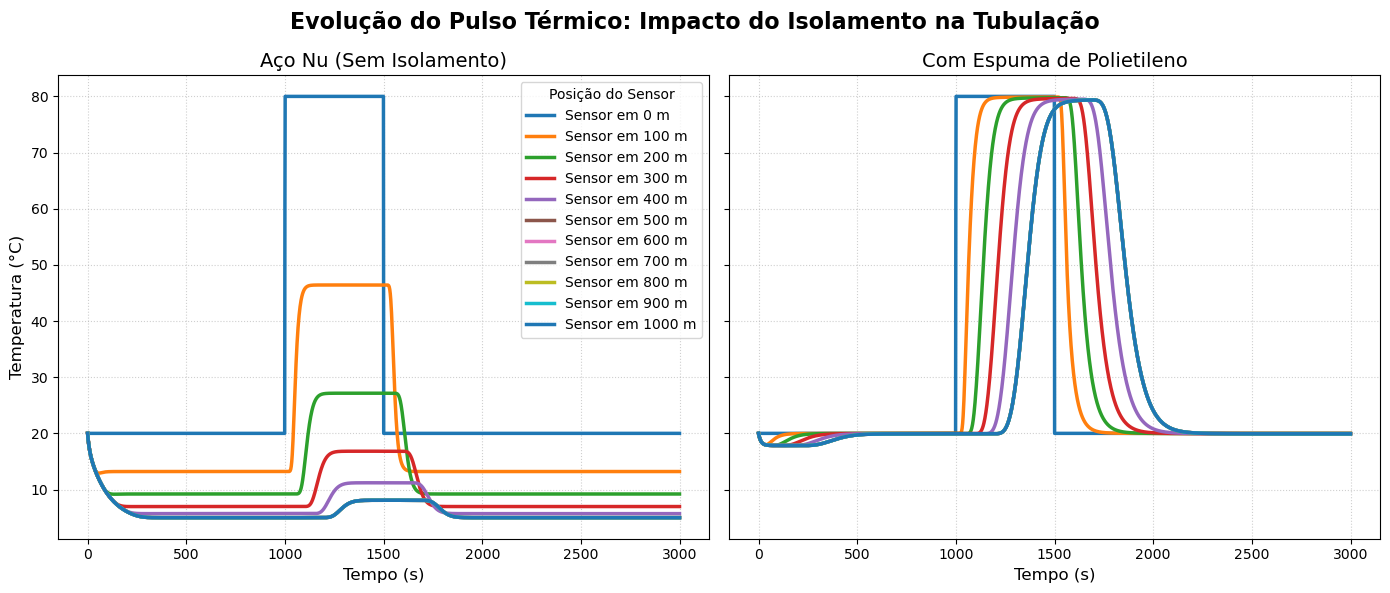

In [6]:
# Cria figura com 1 linha e 2 colunas
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Evolução do Pulso Térmico: Impacto do Isolamento na Tubulação", fontsize=16, fontweight='bold')

# Filtro para plotar apenas os 3 primeiros sensores definidos (0m, 100m e 200m)
#sensores_plaot = [secoes_monitoradas[i] for i in range(len(secoes_monitoradas)-7)]

for idx, c in enumerate(casos_estudo):
    ax = axs[idx]
    pasta_resultados = f"resultados_{c['nome']}"
    
    for pos in secoes_monitoradas:
        caminho = os.path.join(pasta_resultados, f"TENDP-{pos}.dat")
        if os.path.exists(caminho):
            df = pd.read_csv(caminho, sep=';', skiprows=3)
            ax.plot(df[' Tempo (s) '], df[' Temperatura (C) '], label=f'Sensor em {pos} m', lw=2.5)
            
    # Formatação de cada subplot
    ax.set_title(c["titulo"], fontsize=14)
    ax.set_xlabel("Tempo (s)", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if idx == 0:
        ax.set_ylabel("Temperatura (°C)", fontsize=12)
        ax.legend(title="Posição do Sensor", loc='upper right')

plt.tight_layout()
plt.show()

## 6. Conclusão

Ao analisar os gráficos lado a lado percebe-se claramente o impacto físico do revestimento térmico no comportamento do fluido. A propagação da onda de calor obedece diretamente à resistência térmica radial da parede do duto.

**Tubo de Aço Nu sem Isolamento**

O aço carbono possui uma alta condutividade térmica próxima de 45 W/m.K. Como a resistência à transferência de calor é muito pequena, a energia térmica injetada pelo pulso quente é dissipada rapidamente para o ambiente submarino a 4 °C. No primeiro gráfico a temperatura do fluido despenca drasticamente logo nas primeiras dezenas de metros. Em uma operação real esse resfriamento abrupto faria o fluido cruzar rapidamente a curva de formação de hidratos ou a temperatura de cristalização de parafinas resultando no entupimento severo da linha.

**Tubo com Isolamento de Espuma de Polietileno**

A adição de 25 mm de um material com baixa condutividade térmica de 0.04 W/m.K altera completamente o perfil do escoamento. A espuma atua como uma barreira física que eleva drasticamente a resistência térmica global. O pulso de calor é preservado e consegue viajar por distâncias muito maiores antes de se dissipar. Além disso, a temperatura de 20 °C da linha é mantida em todo o comprimento da tubulação, o que não acontece no caso sem isolamento. 

O dimensionamento correto do isolamento impede que a temperatura do fluido caia abaixo dos limites críticos durante o trajeto pelo ambiente submarino frio. Com essa retenção térmica evita-se a cristalização de componentes da mistura e a consequente formação de hidratos ou deposição de parafinas garantindo que o escoamento ocorra sem interrupções.